FULL DATA FROM CSV:
      Pt   Pd    Ir    Os  Min OP (mV)  Avg OP (mV)  Std Dev Avg OP (mV)
0   0.00  0.0  0.00  1.00       783.00    793.33333             11.06044
1   0.00  0.0  0.25  0.75       522.00    524.66667              3.05505
2   0.00  0.0  0.50  0.50       518.00    524.66667              7.63763
3   0.00  0.0  0.75  0.25       465.00    466.00000              1.41421
4   0.00  0.0  1.00  0.00       442.00    468.00000             27.05550
..   ...  ...   ...   ...          ...          ...                  ...
61  0.35  0.0  0.65  0.00       416.59    424.92333              7.17403
62  0.20  0.0  0.80  0.00       430.59    441.92333              9.43751
63  0.10  0.0  0.90  0.00       431.59    447.59000             14.32480
64  0.01  0.0  0.99  0.00       407.59    410.92333              4.13118
65  0.00  0.0  1.00  0.00       420.59    441.92333             17.46616

[66 rows x 7 columns]


DATA INFO (shows dtypes and non-null counts):
<class 'pandas.core.frame.DataFra

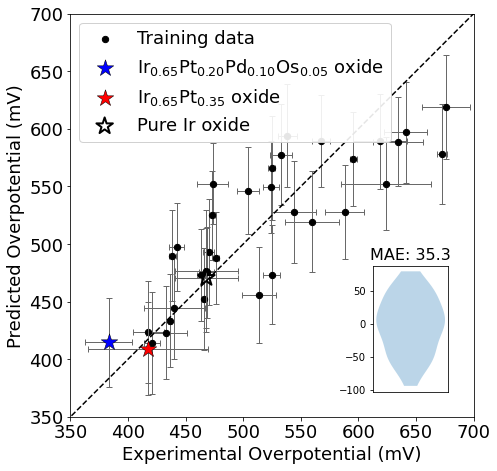


=== Part 1 Complete ===



In [1]:
"""
================================================================================
SUPPLEMENTARY INFORMATION CODE
Gaussian Process Regression Modeling of OER Overpotential vs. Composition
in Pt-Pd-Ir-Os Mixed Oxide Catalysts
================================================================================

OVERVIEW
--------
This script implements a Gaussian Process Regression (GPR) workflow used to:
    (1) Evaluate model performance via leave-one-out cross-validation (LOOCV)
        on an initial training set (Part 1), and generate a parity plot
        comparing experimental vs. predicted overpotentials.
    (2) Verify internal consistency of the composition-screening results
        before using them for any downstream ranking or reporting
        (Consistency Check).
    (3) Rank all screened candidate compositions by predicted overpotential,
        by predictive uncertainty, and by a combined exploration-exploitation
        score, to identify both the best-performing and most-informative
        candidates for future experimental validation (Ranking Block).
    (4) Quantify how leave-one-out cross-validated MAE evolves as
        training-set size grows, contrasting random subsampling of the
        original training set against the sequential, actively-selected
        validation-phase compositions (Learning Curve).
    (5) Visualize how the predicted overpotential changes as each
        element's fraction is swept away from the optimal composition
        (Ir0.65 Pt0.20 Pd0.10 Os0.05), with the other three elements'
        relative proportions held fixed (Element Sensitivity Analysis).
    (6) Quantify each element's contribution to the model's predicted
        overpotential using SHAP (SHapley Additive exPlanations) values,
        visualized as a beeswarm summary plot (SHAP Analysis). Requires
        the `shap` package (pip install shap), which is not otherwise
        used in this script.
    (7) Re-train the GPR model on the complete dataset (all measured
        compositions, Part 2) and screen a comprehensive grid of candidate
        Pt-Pd-Ir-Os compositions to identify the composition(s) predicted
        to exhibit the lowest oxygen evolution reaction (OER) overpotential
        once all data are incorporated into training.
    (8) Visualize how well the fully-trained (Part 2) model reproduces the
        complete experimental dataset via an in-sample parity plot
        (Full-Dataset Parity Plot). This is explicitly NOT a cross-validated
        estimate of generalization -- see the caveat in that section.

RUN ORDER (IMPORTANT)
-----------------------
This script must be executed top to bottom, in a single uninterrupted
kernel/session, in exactly this order:

    Part 1  -->  Consistency Check  -->  Ranking Block  -->  Learning Curve
    -->  Element Sensitivity Analysis  -->  SHAP Analysis  -->  Part 2  -->
    Full-Dataset Parity Plot

The Learning Curve, Element Sensitivity Analysis, and SHAP Analysis
sections all depend on Part 1's u, s, invScaling, and pipe (its
training-set-only standardization constants and fitted model object), and
on X_all/y_all as defined by the Learning Curve (i.e., the <700 mV
filtered train+validation combination -- the SHAP Analysis intentionally
explains the model using only this filtered set, not every measured
composition). All three must run BEFORE Part 2, which redefines u, s,
invScaling, X, y, and pipe for the independently-trained full-dataset
model. Running any of them after Part 2 would silently apply the wrong
standardization to Part-1-scale quantities and produce incorrect results.
A font-restoration step immediately follows the SHAP Analysis to
counteract its plt.style.use('default') call, ensuring every figure in
this script (before and after that point) uses the same font family.

The Consistency Check and Ranking Block both operate on variables produced
by Part 1 (X_all_compositions, y_all_pred, y_all_std, pipe) and do not
recompute or reload anything themselves. Part 2 subsequently REDEFINES
pipe, X, y, u, s, and invScaling for an independently-trained model fit on
the complete dataset; consequently, Part 2 must be run LAST. Re-running
Part 1 partially, running cells out of order, or running Part 2 before the
Learning Curve / Element Sensitivity Analysis will either cause the
Consistency Check to fail (by design -- see the Consistency Check section
below) or silently apply the wrong standardization constants (see the
caveats in those sections). Either symptom should be treated as a signal
to restart the kernel and re-run the full script from the top.

DATA
----
Input file: "EC data_std dev.csv"
Each row corresponds to one measured electrochemical sample and contains:
    - Composition fractions: Pt, Pd, Ir, Os (mole fractions summing to 1)
    - Avg OP (mV): measured average overpotential at a fixed current density
    - Std Dev Avg OP (mV): standard deviation of replicate overpotential
      measurements for that sample

Samples are indexed 1-55. For Part 1, samples 1-38 are treated as the
"training" set and samples 39-55 as an independent "validation" set (i.e.,
a chronological / temporal train-test split reflecting the order in which
compositions were synthesized and measured, rather than a random split).

Duplicate compositions (i.e., the same nominal Pt/Pd/Ir/Os composition
measured more than once) are consolidated by averaging the measured
overpotential and propagating the associated measurement uncertainty
in quadrature (error propagation for a mean of independent measurements):

    sigma_avg = sqrt( sum_i sigma_i^2 ) / n

MODELING APPROACH
------------------
- Model: Gaussian Process Regression (scikit-learn GaussianProcessRegressor)
- Kernel: RBF() + WhiteKernel()
    - RBF (radial basis function / squared-exponential) kernel captures
      smooth, nonlinear dependence of overpotential on composition.
    - WhiteKernel adds an independent noise term, accounting for
      experimental measurement noise and improving numerical stability
      of the covariance matrix.
  Kernel hyperparameters (length scale, noise level) are optimized
  automatically by scikit-learn via maximization of the log marginal
  likelihood (the default optimizer, L-BFGS-B, with default initial
  hyperparameter values and no explicit random restarts).
- Preprocessing: features (Pt, Pd, Ir, Os) are standardized (zero mean,
  unit variance) via StandardScaler prior to GPR fitting, using an
  sklearn Pipeline.
- Target transformation: the target variable (overpotential, mV) is
  standardized using the mean (u) and standard deviation (s) of the
  TRAINING set only, i.e.:
        y_normalized = (y - u) / s
  Predictions are transformed back to physical units (mV) via the
  inverse transform:
        y_physical = y_normalized * s + u
  This is implemented locally as the function invScaling() in each part.

VALIDATION STRATEGY
--------------------
Part 1 uses leave-one-out cross-validation (LOOCV) on the training set
(samples 1-38, after duplicate-averaging and filtering to overpotentials
< 700 mV) to assess predictive performance without information leakage:
for each of N training points, a GPR model is trained on the remaining
N-1 points and used to predict the held-out point. Mean absolute error
(MAE) is reported from the aggregated LOOCV residuals.

An independent validation set (samples 39-55) is also evaluated using the
final model trained on the full (filtered) training set. This validation
set was not used during model fitting or hyperparameter selection.

COMPOSITION SCREENING
-----------------------
To identify candidate optimal compositions, both Part 1 and Part 2
generate an exhaustive grid of Pt/Pd/Ir/Os compositions on a 0.05
increment simplex (all non-negative combinations of the four elements
summing to 1, in steps of 0.05), and evaluate the trained GPR model's
posterior mean (predicted overpotential) and posterior standard
deviation (predictive uncertainty) at every grid point.

KEY DIFFERENCE BETWEEN PART 1 AND PART 2 MODELS
-------------------------------------------------
Part 1's global-minimum search and validation-set predictions use a GPR
model trained ONLY on the training set (samples 1-38, duplicate-averaged,
and further filtered to overpotentials < 700 mV to exclude points
considered unreliable/outlying for training purposes).

Part 2 re-loads the raw data and trains an independent GPR model on ALL
55 samples (duplicate-averaged, with NO overpotential filter applied).
This second model is intended to represent the outcome of incorporating
all subsequently collected (validation) data into the training set
(e.g., before/after an active-learning-style data acquisition round).
Because the two models differ in (a) training set composition/size and
(b) target standardization constants (u, s recomputed from each
respective training set), their outputs -- including the composition
identified as having the lowest predicted overpotential -- are not
expected to be numerically identical between Part 1 and Part 2, and
should be interpreted as two separate model instances rather than a
single continuously updated model.

REPRODUCIBILITY NOTES
-----------------------
- GaussianProcessRegressor's internal hyperparameter optimizer is
  deterministic given identical training data, kernel initialization,
  and scikit-learn version (no random seed is required unless
  n_restarts_optimizer > 0 is used, which is not the case here).
- All figures are saved in vector format (SVG, and PDF where noted) to
  the working directory for direct use in publication figures.
- Software: developed and tested with numpy, pandas, matplotlib, and
  scikit-learn (see import statements below for exact module usage).

The code below is presented exactly as executed for the results reported
in the manuscript; no functional modifications have been made. Section
headers and inline comments have been added/expanded for clarity in this
Supplementary Information listing.
================================================================================
"""

# ==============================================================================
# ==============================================================================
#   PART 1
#   Cross-validation of the GPR model on the initial training set (samples
#   1-38), generation of the experimental-vs-predicted parity plot, and
#   identification of the globally optimal composition predicted from the
#   training-set-only model.
# ==============================================================================
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor as GPR
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error as mae
from matplotlib.ticker import MultipleLocator
import itertools

# Set font - try Arial, fall back to Helvetica or DejaVu Sans
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['font.family'] = 'sans-serif'

# Enable LaTeX rendering for subscripts
plt.rcParams['text.usetex'] = False  # Use mathtext, not full LaTeX

# ============================================================================
# PART 1: Cross-Validation and Model Evaluation
# ============================================================================

# ---- Data import ----
# Load full data
data_full = pd.read_csv("EC data_std dev.csv", header=0)

print("="*80)
print("FULL DATA FROM CSV:")
print("="*80)
print(data_full)
print("\n")

print("="*80)
print("DATA INFO (shows dtypes and non-null counts):")
print("="*80)
print(data_full.info())
print("\n")

# ---- Data quality check: missing values ----
print("="*80)
print("CHECKING FOR NaN VALUES:")
print("="*80)
print("NaN count per column:")
print(data_full.isna().sum())
print("\n")

print("Rows with NaN values:")
rows_with_nan = data_full[data_full.isna().any(axis=1)]
print(rows_with_nan)
print(f"\nTotal rows with NaN: {len(rows_with_nan)}")
print("\n")

# Drop rows with any NaN values (optional if already cleaned)
data_full = data_full.dropna()
print(f"Data after removing NaN values: {len(data_full)} rows")

# Reset index
data_full = data_full.reset_index(drop=True)

# ---- Train / validation split ----
# Split based on row numbers (1-38 vs 39-55). This is a chronological split:
# samples 1-38 were used to build the initial GPR model; samples 39-55 were
# collected afterward and reserved as an independent validation set.
data_train_all = data_full.iloc[:38].copy()  # First 38 rows (samples 1-38)
data_validation_all = data_full.iloc[38:].copy()  # Rows 39+ (samples 39-55)

# ---- Duplicate-composition consolidation ----
# Function to average duplicate compositions
def average_duplicates(data):
    """
    For duplicate compositions, average the overpotentials and propagate uncertainties.
    Error propagation for average: σ_avg = sqrt(σ1² + σ2² + ...) / n
    """
    # Group by composition columns
    grouped = data.groupby(['Pt', 'Pd', 'Ir', 'Os'])
    
    # Create lists to store results
    averaged_data = []
    
    for composition, group in grouped:
        if len(group) > 1:
            print(f"\nFound {len(group)} duplicates for composition: Pt={composition[0]}, Pd={composition[1]}, Ir={composition[2]}, Os={composition[3]}")
            print(f"  Original OPs: {group['Avg OP (mV)'].values}")
            print(f"  Original errors: {group['Std Dev Avg OP (mV)'].values}")
        
        # Average the overpotentials
        avg_op = group['Avg OP (mV)'].mean()
        
        # Propagate uncertainties: σ_avg = sqrt(sum of σ_i²) / n
        # This is the correct formula for error in the mean
        std_dev_avg = np.sqrt(np.sum(group['Std Dev Avg OP (mV)'].values**2)) / len(group)
        
        if len(group) > 1:
            print(f"  Averaged OP: {avg_op:.2f} ± {std_dev_avg:.2f} mV")
        
        # Create averaged row
        avg_row = {
            'Pt': composition[0],
            'Pd': composition[1],
            'Ir': composition[2],
            'Os': composition[3],
            'Avg OP (mV)': avg_op,
            'Std Dev Avg OP (mV)': std_dev_avg
        }
        averaged_data.append(avg_row)
    
    return pd.DataFrame(averaged_data)

# Average duplicates in training data
print("\n" + "="*80)
print("AVERAGING DUPLICATE COMPOSITIONS IN TRAINING DATA (samples 1-38):")
print("="*80)
data_train_all_averaged = average_duplicates(data_train_all)
print(f"\nTraining data: {len(data_train_all)} rows → {len(data_train_all_averaged)} unique compositions")

# Average duplicates in validation data
print("\n" + "="*80)
print("AVERAGING DUPLICATE COMPOSITIONS IN VALIDATION DATA (samples 39-55):")
print("="*80)
data_validation_all_averaged = average_duplicates(data_validation_all)
print(f"Validation data: {len(data_validation_all)} rows → {len(data_validation_all_averaged)} unique compositions")

# ---- Training-set filtering ----
# Filter training data to only include overpotentials < 700 mV
# (excludes compositions considered unreliable/outlying for model training)
data_train = data_train_all_averaged[data_train_all_averaged['Avg OP (mV)'] < 700].copy()

# Keep ALL validation data (no overpotential filter)
data_validation = data_validation_all_averaged.copy()

print(f"\nFinal training data (< 1000 mV only): {len(data_train)} unique compositions")
print(f"Final validation data (all overpotentials): {len(data_validation)} unique compositions")

# ---- Feature / target extraction ----
# Extract features (Pt, Pd, Ir, Os) and target (Avg OP)
X_train_full = data_train[['Pt', 'Pd', 'Ir', 'Os']].values
y_train_full = data_train['Avg OP (mV)'].values
y_train_std = data_train['Std Dev Avg OP (mV)'].values  # Experimental uncertainties

X_validation = data_validation[['Pt', 'Pd', 'Ir', 'Os']].values
y_validation = data_validation['Avg OP (mV)'].values
y_validation_std = data_validation['Std Dev Avg OP (mV)'].values  # Experimental uncertainties

# ---- Target standardization ----
# Normalize target variable using training data statistics
u = np.mean(y_train_full)
s = np.std(y_train_full)
y_train_normalized = (y_train_full - u) / s

def invScaling(y_scaled):
    return np.array(y_scaled) * s + u

print("\nFeature Matrix (X) shape:", X_train_full.shape)
print("Target (y) shape:", y_train_full.shape)

# ---- Model definition ----
# Define kernel and model for cross-validation
kernel = RBF() + WhiteKernel()
model = GPR(kernel)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', model),
])

# ---- Leave-one-out cross-validation (LOOCV) ----
# Leave-one-out cross validation on training data
kf = KFold(n_splits=len(y_train_normalized))

all_predictions = []
all_uncertainties = []
test_error_list = []

print("\nPerforming leave-one-out cross-validation...")
for train_index, test_index in kf.split(X_train_full):
    X_train, X_test = X_train_full[train_index], X_train_full[test_index]
    y_train, y_test = y_train_normalized[train_index], y_train_normalized[test_index]

    pipe.fit(X_train, y_train)

    y_test_pred, y_test_std = pipe.predict(X_test, return_std=True)
    print(y_test_std)
    
    all_predictions.append(y_test_pred[0])
    all_uncertainties.append(y_test_std[0])
    test_error_list.append(y_test_pred[0] - y_test[0])

# Convert back to original scale
y_original = invScaling(y_train_normalized)
predictions_original = invScaling(all_predictions)
uncertainties_original = np.array(all_uncertainties) * s
errors_original = np.array(test_error_list) * s

# ---- Final model fit (all training data) ----
# Train final model on all training points for validation predictions
pipe.fit(X_train_full, y_train_normalized)

# ---- Exhaustive composition-space screening ----
# Generate all possible compositions to find the global minimum
values = np.arange(0, 1.05, 0.05)
all_combinations = list(itertools.product(values, repeat=4))
valid_combinations = [c for c in all_combinations if abs(sum(c) - 1) < 1e-9]
X_all_compositions = np.array(valid_combinations)

print(f"\nGenerating predictions for {len(X_all_compositions)} possible compositions...")

# Predict for all compositions
y_all_pred_norm, y_all_std_norm = pipe.predict(X_all_compositions, return_std=True)
y_all_pred = invScaling(y_all_pred_norm)
y_all_std = y_all_std_norm * s

# Find the composition with the lowest predicted overpotential
min_idx = np.argmin(y_all_pred)
min_composition = X_all_compositions[min_idx]
min_overpotential = y_all_pred[min_idx]
min_uncertainty = y_all_std[min_idx]

min_label = f'Ir$_{{{min_composition[2]:.2f}}}$Pt$_{{{min_composition[0]:.2f}}}$Pd$_{{{min_composition[1]:.2f}}}$Os$_{{{min_composition[3]:.2f}}}$ oxide'

print(f"\nGlobal minimum predicted overpotential:")
print(f"  Composition: {min_label}")
print(f"  Predicted OP: {min_overpotential:.1f} ± {min_uncertainty:.1f} mV")

# ---- Validation-set evaluation ----
# Select top 3 validation points with lowest EXPERIMENTAL overpotentials
if len(X_validation) > 0:
    # Predict validation set (for plotting purposes)
    y_validation_pred_norm, y_validation_std_norm = pipe.predict(X_validation, return_std=True)
    y_validation_pred = invScaling(y_validation_pred_norm)
    y_validation_pred_std = y_validation_std_norm * s

    # Sort by EXPERIMENTAL overpotential (not predicted)
    n_top = min(3, len(y_validation))
    top_indices = np.argsort(y_validation)[:n_top]
    
    X_validation_top3 = X_validation[top_indices]
    y_validation_top3 = y_validation[top_indices]
    y_validation_std_top3 = y_validation_std[top_indices]
    y_validation_pred_top3 = y_validation_pred[top_indices]
    y_validation_pred_std_top3 = y_validation_pred_std[top_indices]
    
    print(f"\nShowing top {n_top} validation points with lowest EXPERIMENTAL overpotential")

    # Create simple text labels - NO LaTeX
    validation_labels = []
        
    for i in range(len(X_validation_top3)):
        label = f'Ir$_{{{X_validation_top3[i, 2]:.2f}}}$Pt$_{{{X_validation_top3[i, 0]:.2f}}}$Pd$_{{{X_validation_top3[i, 1]:.2f}}}$Os$_{{{X_validation_top3[i, 3]:.2f}}}$ oxide'
        validation_labels.append(label)
    
    # Print the top 3 validation compositions
    print(f"\nTop {n_top} validation set compositions (lowest EXPERIMENTAL overpotential):")
    for i in range(n_top):
        print(f"  {validation_labels[i]}: Exp={y_validation_top3[i]:.1f} ± {y_validation_std_top3[i]:.1f} mV, Pred={y_validation_pred_top3[i]:.1f} ± {y_validation_pred_std_top3[i]:.1f} mV")
else:
    print("No validation data available after filtering")
    n_top = 0
    
# ---- Parity plot: experimental vs. predicted overpotential ----
# Create cross-validation plot
plt.figure(figsize=(7, 7))

# Plot training data cross-validation results with horizontal experimental error bars
plt.errorbar(y_original, predictions_original, 
             xerr=y_train_std,  # Horizontal error bars (experimental uncertainty)
             yerr=uncertainties_original,  # Vertical error bars (prediction uncertainty)
             marker='None', color='dimgray', linestyle='None', 
             linewidth=1, capsize=3, capthick=1, zorder=1)
plt.scatter(y_original, predictions_original, marker='o', s=40, color='black',
           zorder=2, label='Training data')

# Selected compositions of particular interest, highlighted individually on the
# parity plot (e.g., best-performing catalyst and relevant benchmark/reference
# compositions such as the Ir65Pt35 binary and pure Ir oxide)
specific_compositions = np.array([
    [0.20, 0.10, 0.65, 0.05],  # Ir65Pt20Pd10Os5
    [0.35, 0.00, 0.65, 0.00],  # Ir65Pt35Pd0Os0
    [0.00, 0.00, 1.00, 0.00],  # Pure Ir oxide
])
specific_labels = [
    r'Ir$_{0.65}$Pt$_{0.20}$Pd$_{0.10}$Os$_{0.05}$ oxide',
    r'Ir$_{0.65}$Pt$_{0.35}$ oxide',
    r'Pure Ir oxide',
]

specific_exp = np.array([383.39, 417.4, 468])
specific_exp_std = np.array([20.36, 52.2, 27.0555])

# Predict for specific compositions
y_specific_norm, y_specific_std_norm = pipe.predict(specific_compositions, return_std=True)
y_specific_pred = invScaling(y_specific_norm)
y_specific_std = y_specific_std_norm * s

specific_colors = ['blue', 'red', 'black']
for i in range(len(specific_compositions)):
    plt.errorbar(specific_exp[i], y_specific_pred[i],
                xerr=specific_exp_std[i],
                yerr=y_specific_std[i],
                marker='None', color='dimgray', linestyle='None',
                linewidth=1, capsize=3, capthick=1, zorder=2)

    if specific_labels[i] == r'Pure Ir oxide':
        # Outline-only star, drawn on top of everything (including training data)
        plt.scatter(specific_exp[i], y_specific_pred[i], marker='*', s=300,
                   facecolors='none', edgecolors='black', linewidth=2,
                   zorder=4, label=specific_labels[i])
    else:
        plt.scatter(specific_exp[i], y_specific_pred[i], marker='*', s=300,
                   color=specific_colors[i], edgecolors='black', linewidth=0.5,
                   zorder=3, label=specific_labels[i])
        
# Diagonal line (parity / y = x reference line)
plt.plot([300, 700], [300, 700], 'k--')
plt.xlim(350, 700)
plt.ylim(350, 700)
plt.xlabel('Experimental Overpotential (mV)', fontsize=18)
plt.ylabel('Predicted Overpotential (mV)', fontsize=18)
plt.tick_params(labelsize=18)
plt.legend(fontsize=18, loc='upper left', framealpha=0.9)

# Inset violin plot showing the distribution of LOOCV residuals (only for
# training data), annotated with the mean absolute error (MAE)
inset = plt.axes([.75, .2, .15, .25])
plt.violinplot(errors_original, showextrema=False)
plt.xticks([])
plt.title(f'MAE: {np.mean(np.abs(errors_original)):.1f}', fontsize=16)

plt.subplots_adjust(top=0.95, bottom=0.15, left=0.15, right=0.95)

# Save figures
plt.savefig('overpotential_prediction.svg', format='svg', bbox_inches='tight')

plt.show()

print("\n=== Part 1 Complete ===\n")

In [2]:
# ==============================================================================
# ==============================================================================
#   CONSISTENCY CHECK
#   Verifies, before any downstream ranking or reporting is performed, that
#   (a) every candidate composition in X_all_compositions is a valid point
#   on the Pt/Pd/Ir/Os simplex (fractions summing to 1), and (b) the
#   composition identified as rank 0 in the ranking block below is
#   identical to the global-minimum composition already reported by
#   Part 1. Because both quantities are derived from argsort/argmin over
#   the exact same y_all_pred array, a mismatch is only possible if these
#   variables were not evaluated consecutively within the same run (e.g.,
#   Part 1 was partially re-executed, or a different cell redefined these
#   variables in between). This check exists to make any such run-order
#   error immediately visible rather than silently producing a misleading
#   ranking plot.
# ==============================================================================
# ==============================================================================

# ---- Check 1: composition validity ----
comp_sums = X_all_compositions.sum(axis=1)
bad_rows = np.where(np.abs(comp_sums - 1) > 1e-6)[0]

print(f"Total compositions: {len(X_all_compositions)}")
print(f"Compositions NOT summing to 1 (tolerance 1e-6): {len(bad_rows)}")
if len(bad_rows) > 0:
    print("  First few offending rows:")
    for i in bad_rows[:5]:
        print(f"    index {i}: {X_all_compositions[i]}  (sum={comp_sums[i]:.6f})")
    print("  --> X_all_compositions appears corrupted or stale. "
          "Re-run Part 1 from the top before proceeding.")
else:
    print("  OK: all compositions sum to 1.")

# ---- Check 2: rank-0 composition matches Part 1's own reported minimum ----
idx_perf = np.argsort(y_all_pred)
rank0_idx = idx_perf[0]
min_idx = np.argmin(y_all_pred)

print("\n--- Comparing ranking script rank-0 vs. Part 1's global minimum ---")
print(f"Part 1 min_idx:            {min_idx}")
print(f"Ranking script rank0_idx:  {rank0_idx}")
print(f"Indices match: {min_idx == rank0_idx}")

print(f"\nPart 1 composition (min_composition): {X_all_compositions[min_idx]}")
print(f"Ranking rank-0 composition:            {X_all_compositions[rank0_idx]}")
print(f"Predicted OP match: {np.isclose(y_all_pred[min_idx], y_all_pred[rank0_idx])}")

if min_idx != rank0_idx:
    print("\n*** MISMATCH DETECTED ***")
    print("This should be mathematically impossible if X_all_compositions and")
    print("y_all_pred are the exact same arrays in both places. This means")
    print("one of the two blocks ran against a different/stale version of")
    print("these variables (most likely cause: cells executed out of order,")
    print("or Part 1 was re-run with different data/kernel fit results")
    print("in between the two comparisons). Re-run Part 1 completely, then")
    print("immediately run the ranking script without executing any other")
    print("cell in between.")
else:
    print("\nOK: rank-0 composition and value are fully consistent with Part 1.")

print("\n=== Consistency Check Complete ===\n")

Total compositions: 1771
Compositions NOT summing to 1 (tolerance 1e-6): 0
  OK: all compositions sum to 1.

--- Comparing ranking script rank-0 vs. Part 1's global minimum ---
Part 1 min_idx:            1237
Ranking script rank0_idx:  1237
Indices match: True

Part 1 composition (min_composition): [0.35 0.05 0.6  0.  ]
Ranking rank-0 composition:            [0.35 0.05 0.6  0.  ]
Predicted OP match: True

OK: rank-0 composition and value are fully consistent with Part 1.

=== Consistency Check Complete ===



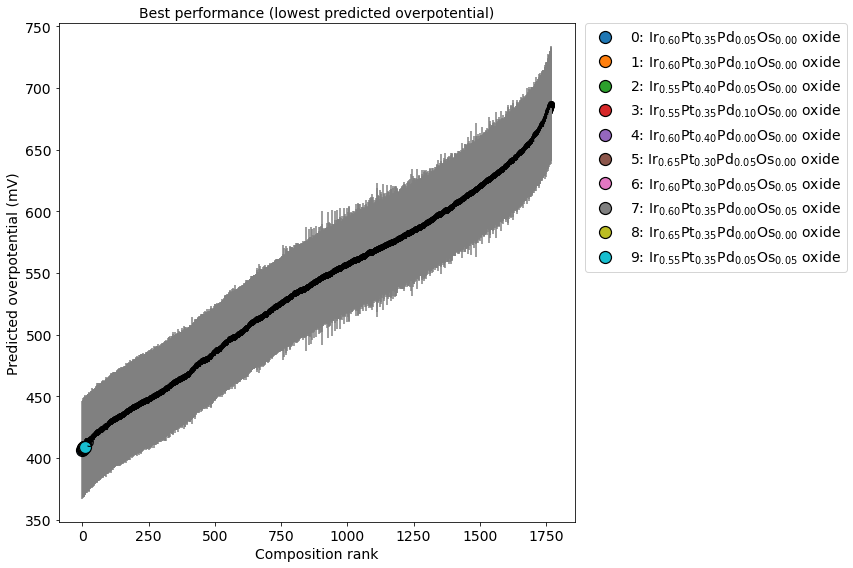

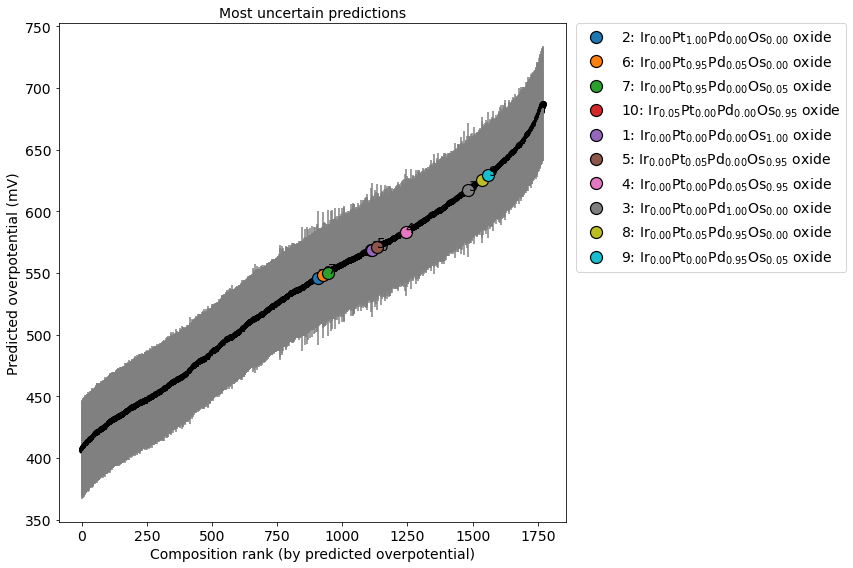

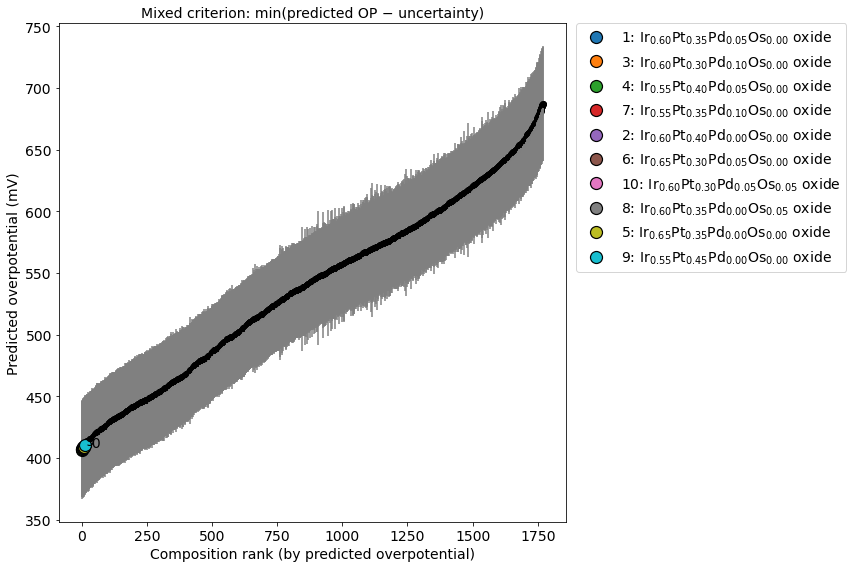


Top candidates by uncertainty (most uncertain):
  1: Ir$_{0.00}$Pt$_{0.00}$Pd$_{0.00}$Os$_{1.00}$ oxide — Pred=568.8 ± 54.4 mV
  2: Ir$_{0.00}$Pt$_{1.00}$Pd$_{0.00}$Os$_{0.00}$ oxide — Pred=545.9 ± 54.2 mV
  3: Ir$_{0.00}$Pt$_{0.00}$Pd$_{1.00}$Os$_{0.00}$ oxide — Pred=617.1 ± 54.1 mV
  4: Ir$_{0.00}$Pt$_{0.00}$Pd$_{0.05}$Os$_{0.95}$ oxide — Pred=582.9 ± 51.3 mV
  5: Ir$_{0.00}$Pt$_{0.05}$Pd$_{0.00}$Os$_{0.95}$ oxide — Pred=571.1 ± 51.3 mV
  6: Ir$_{0.00}$Pt$_{0.95}$Pd$_{0.05}$Os$_{0.00}$ oxide — Pred=548.4 ± 51.2 mV
  7: Ir$_{0.00}$Pt$_{0.95}$Pd$_{0.00}$Os$_{0.05}$ oxide — Pred=549.8 ± 51.2 mV
  8: Ir$_{0.00}$Pt$_{0.05}$Pd$_{0.95}$Os$_{0.00}$ oxide — Pred=625.5 ± 51.2 mV
  9: Ir$_{0.00}$Pt$_{0.00}$Pd$_{0.95}$Os$_{0.05}$ oxide — Pred=629.4 ± 51.2 mV
  10: Ir$_{0.05}$Pt$_{0.00}$Pd$_{0.00}$Os$_{0.95}$ oxide — Pred=568.8 ± 50.3 mV

Top candidates by mixed score (low OP, high uncertainty):
  1: Ir$_{0.60}$Pt$_{0.35}$Pd$_{0.05}$Os$_{0.00}$ oxide — Pred=406.3 ± 39.6 mV, score=366.7
  2: Ir$_

In [3]:

# ==============================================================================
# ==============================================================================
#   RANKING BLOCK
#   Ranks all screened candidate compositions (from Part 1's exhaustive grid
#   search) along three criteria relevant to selecting the next experiments:
#     (i)   lowest predicted overpotential ("best performance"),
#     (ii)  highest predictive (posterior) uncertainty -- i.e., compositions
#           the model is currently least confident about, which are
#           informative candidates for reducing model uncertainty, and
#     (iii) a combined score, predicted_overpotential - uncertainty, which
#           favors compositions that are both promising AND poorly
#           constrained -- a simple exploration-exploitation criterion
#           relevant to active-learning-guided experimental design.
#   This block operates entirely on X_all_compositions, y_all_pred, and
#   y_all_std as produced by Part 1; no data are reloaded and no model is
#   refit here.
#
#   LEGIBILITY ADJUSTMENTS (relative to the original block): axis/title/
#   legend font sizes increased to 14pt; highlighted (top-10) points are
#   now drawn larger (markersize=12) with a black outline and a higher
#   z-order, so they are clearly visible against the dense gray
#   posterior-uncertainty error bars rather than being visually lost in
#   them; the legend is placed outside the plot axes (to the right)
#   rather than overlapping the data, since the larger legend font would
#   otherwise obscure part of the curve; figure width increased slightly
#   to accommodate the external legend.
# ==============================================================================
# ==============================================================================
 
# ============================================================================
# PART 2: Rank Compositions by Prediction Uncertainty
# ============================================================================
 
# Helper to build a readable composition label (matches style used above)
def composition_label(comp):
    pt, pd_, ir, os_ = comp
    return f'Ir$_{{{ir:.2f}}}$Pt$_{{{pt:.2f}}}$Pd$_{{{pd_:.2f}}}$Os$_{{{os_:.2f}}}$ oxide'
 
n_highlight = 10  # how many top points to label/highlight
 
# --- Rank by predicted overpotential (best performance) ---
idx_perf = np.argsort(y_all_pred)
 
plt.figure(figsize=(12, 8))
for rank, i in enumerate(idx_perf):
    plt.errorbar(rank, y_all_pred[i], yerr=y_all_std[i],
                 marker='None', color='gray', linestyle='None', zorder=1)
    if rank < n_highlight:
        plt.plot(rank, y_all_pred[i], marker='o', markersize=12,
                  markeredgecolor='black', markeredgewidth=1.2,
                  linestyle='None', zorder=3,
                  label=f'{rank}: {composition_label(X_all_compositions[i])}')
        plt.annotate(str(rank), (rank + 0.2, y_all_pred[i]), fontsize=14)
    else:
        plt.plot(rank, y_all_pred[i], marker='o', color='k', linestyle='None', zorder=1)
plt.xlabel('Composition rank', fontsize=14)
plt.ylabel('Predicted overpotential (mV)', fontsize=14)
plt.title('Best performance (lowest predicted overpotential)', fontsize=14)
plt.tick_params(labelsize=14)
plt.legend(fontsize=14, loc='upper left', bbox_to_anchor=(1.02, 1.0),
           borderaxespad=0)
plt.tight_layout()
plt.savefig('ranked_best_performance.svg', format='svg', bbox_inches='tight')
plt.show()
 
# --- Rank by uncertainty (most uncertain predictions) ---
idx_unc = np.argsort(y_all_std)[::-1][:n_highlight]  # indices of top-N most uncertain
 
plt.figure(figsize=(12, 8))
for rank, i in enumerate(idx_perf):  # keep same x-axis ordering (by performance) for comparison
    plt.errorbar(rank, y_all_pred[i], yerr=y_all_std[i],
                 marker='None', color='gray', linestyle='None', zorder=1)
    if i in idx_unc:
        label_rank = list(idx_unc).index(i) + 1
        plt.plot(rank, y_all_pred[i], marker='o', markersize=12,
                  markeredgecolor='black', markeredgewidth=1.2,
                  linestyle='None', zorder=3,
                  label=f'{label_rank}: {composition_label(X_all_compositions[i])}')
        plt.annotate(str(label_rank), (rank + 0.2, y_all_pred[i]), fontsize=14)
    else:
        plt.plot(rank, y_all_pred[i], marker='o', color='k', linestyle='None', zorder=1)
plt.xlabel('Composition rank (by predicted overpotential)', fontsize=14)
plt.ylabel('Predicted overpotential (mV)', fontsize=14)
plt.title('Most uncertain predictions', fontsize=14)
plt.tick_params(labelsize=14)
plt.legend(fontsize=14, loc='upper left', bbox_to_anchor=(1.02, 1.0),
           borderaxespad=0)
plt.tight_layout()
plt.savefig('ranked_most_uncertain.svg', format='svg', bbox_inches='tight')
plt.show()
 
# --- Mixed criterion: minimize (predicted overpotential - uncertainty) ---
# This favors compositions that are both low-overpotential AND poorly constrained,
# i.e. good candidates for the next experiment (exploration-exploitation tradeoff).
mix_score = y_all_pred - y_all_std
idx_mix = np.argsort(mix_score)[:n_highlight]
 
plt.figure(figsize=(12, 8))
for rank, i in enumerate(idx_perf):
    plt.errorbar(rank, y_all_pred[i], yerr=y_all_std[i],
                 marker='None', color='gray', linestyle='None', zorder=1)
    if i in idx_mix:
        label_rank = list(idx_mix).index(i) + 1
        plt.plot(rank, y_all_pred[i], marker='o', markersize=12,
                  markeredgecolor='black', markeredgewidth=1.2,
                  linestyle='None', zorder=3,
                  label=f'{label_rank}: {composition_label(X_all_compositions[i])}')
        plt.annotate(str(label_rank), (rank + 0.2, y_all_pred[i]), fontsize=14)
    else:
        plt.plot(rank, y_all_pred[i], marker='o', color='k', linestyle='None', zorder=1)
plt.xlabel('Composition rank (by predicted overpotential)', fontsize=14)
plt.ylabel('Predicted overpotential (mV)', fontsize=14)
plt.title('Mixed criterion: min(predicted OP − uncertainty)', fontsize=14)
plt.tick_params(labelsize=14)
plt.legend(fontsize=14, loc='upper left', bbox_to_anchor=(1.02, 1.0),
           borderaxespad=0)
plt.tight_layout()
plt.savefig('ranked_mixed_criterion.svg', format='svg', bbox_inches='tight')
plt.show()
 
# --- Print summary tables ---
print("\nTop candidates by uncertainty (most uncertain):")
for rank, i in enumerate(idx_unc, start=1):
    print(f"  {rank}: {composition_label(X_all_compositions[i])} — "
          f"Pred={y_all_pred[i]:.1f} ± {y_all_std[i]:.1f} mV")
 
print("\nTop candidates by mixed score (low OP, high uncertainty):")
for rank, i in enumerate(idx_mix, start=1):
    print(f"  {rank}: {composition_label(X_all_compositions[i])} — "
          f"Pred={y_all_pred[i]:.1f} ± {y_all_std[i]:.1f} mV, score={mix_score[i]:.1f}")
 
print("\n=== Ranking Block Complete ===\n")
 
 


=== Part 2: Learning Curve ===

Training compositions (<700 mV): 33
Validation compositions (<700 mV): 17
Total compositions in learning curve: 50
Validation points excluded (>=700 mV): 1
Training compositions: 33
Total compositions: 50
Active learning points: 17

Phase 1: Random subsets (n=5 to 33)...


/home/users/ekerr2/.local/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/users/ekerr2/.local/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/users/ekerr2/.local/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/users/ekerr2/.local/lib/python3.9/site-packages/skle

/home/users/ekerr2/.local/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/users/ekerr2/.local/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/users/ekerr2/.local/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/users/ekerr2/.local/lib/python3.9/site-packages/skle

/home/users/ekerr2/.local/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/users/ekerr2/.local/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/users/ekerr2/.local/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/users/ekerr2/.local/lib/python3.9/site-packages/skle

/home/users/ekerr2/.local/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/users/ekerr2/.local/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/users/ekerr2/.local/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/users/ekerr2/.local/lib/python3.9/site-packages/skle

...

/home/users/ekerr2/.local/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/users/ekerr2/.local/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/users/ekerr2/.local/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/users/ekerr2/.local/lib/python3.9/site-packages/skle

/home/users/ekerr2/.local/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/users/ekerr2/.local/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/users/ekerr2/.local/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/users/ekerr2/.local/lib/python3.9/site-packages/skle

  n=30: MAE = 35.9 ± 1.8 mV


/home/users/ekerr2/.local/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


  n=33: MAE = 35.3 ± 0.0 mV

Phase 2: Sequential active learning points (n=34 to 50)...
  n=34: MAE = 35.5 mV  [actively added]
  n=35: MAE = 37.0 mV  [actively added]
  n=36: MAE = 36.5 mV  [actively added]
  n=37: MAE = 36.5 mV  [actively added]
  n=38: MAE = 36.3 mV  [actively added]
  n=39: MAE = 36.4 mV  [actively added]
  n=40: MAE = 35.9 mV  [actively added]
  n=41: MAE = 36.0 mV  [actively added]
  n=42: MAE = 35.4 mV  [actively added]
  n=43: MAE = 34.6 mV  [actively added]
  n=44: MAE = 35.4 mV  [actively added]
  n=45: MAE = 34.6 mV  [actively added]
  n=46: MAE = 34.2 mV  [actively added]
  n=47: MAE = 34.2 mV  [actively added]
  n=48: MAE = 34.0 mV  [actively added]
  n=49: MAE = 33.6 mV  [actively added]
  n=50: MAE = 33.2 mV  [actively added]

Key results:
  MAE at n=33 (before active learning): 35.3 mV
  MAE at n=50 (after active learning):  33.2 mV
  Improvement: 2.0 mV (5.8%)


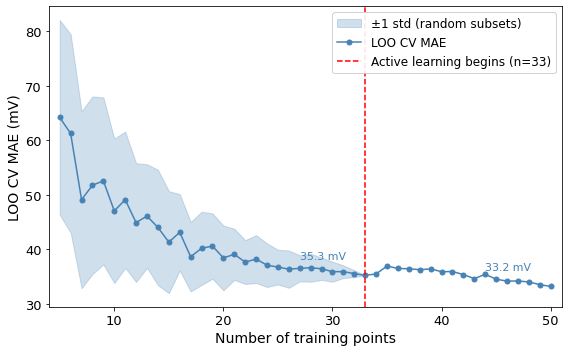


=== Part 2 Complete ===

=== Learning Curve Complete ===



In [4]:
# ==============================================================================
# ==============================================================================
#   LEARNING CURVE
#   Quantifies how leave-one-out cross-validated mean absolute error (MAE)
#   changes as the number of training compositions increases, in order to
#   visualize the benefit of the actively-selected validation-phase
#   compositions (samples 39-55) relative to the original training set
#   (samples 1-38).
#
#   DEPENDENCIES: uses X_train_full, y_train_full, y_train_std,
#   X_validation, y_validation, y_validation_std, u, s, and pipe exactly as
#   produced by Part 1. This section must therefore run BEFORE Part 2,
#   which redefines u, s, and pipe for an independently-trained,
#   full-dataset model; running this section after Part 2 would silently
#   apply the wrong (full-dataset) standardization constants to the
#   Part-1-scale quantities used here and produce incorrect MAE values.
#
#   METHOD:
#     Phase 1 (n = 5 to 38): for each training-set size n, 50 random
#       subsets of size n are drawn (without replacement) from the
#       original 38 training compositions. For each subset, a full
#       leave-one-out cross-validation is performed (refitting the GPR
#       on n-1 points and predicting the held-out point), and the mean
#       absolute LOOCV error is recorded. The mean and standard deviation
#       across the 50 repeats are reported at each n, giving a sense of
#       the sampling variability at small training-set sizes.
#     Phase 2 (n = 39 to 56): compositions from the validation set
#       (samples 39-55, restricted to overpotentials < 700 mV) are added
#       one at a time, IN THE ORDER THEY WERE EXPERIMENTALLY COLLECTED
#       (i.e., not randomly resampled), to reflect the actual sequential,
#       actively-guided data-collection process. LOOCV MAE is recomputed
#       at each cumulative size.
#
#   CAVEATS:
#     - Phase 1 uses np.random.choice without a fixed random seed, so the
#       exact subset draws (and therefore the small run-to-run variation
#       in the shaded uncertainty band) are not deterministic between
#       repeated executions of this script. This does not materially
#       affect the reported trend, but exact figure values may shift
#       slightly between runs. Set a seed (e.g., np.random.seed(0)) before
#       this section if bitwise reproducibility across runs is required.
#     - This section performs a large number of GPR refits (up to 50
#       repeats x up to 34 subset sizes x up to 34 LOOCV folds in Phase 1
#       alone) and may take a non-trivial amount of time to run.
#     - "X_all", "y_all" here refer to the Part-1-scale combined
#       training+validation arrays (filtered to <700 mV) -- these are
#       DIFFERENT arrays from the "X_all"/"y_all" used in the earlier
#       before/after active-learning comparison, and unrelated to
#       "X_all_compositions" (the exhaustive screening grid) used in the
#       Ranking Block. This section also reassigns "y_all_std" to mean
#       EXPERIMENTAL uncertainties of the combined train+validation set,
#       which overwrites/shadows the Ranking Block's "y_all_std" (which
#       held GPR PREDICTIVE uncertainties over the screening grid). The
#       Ranking Block has already finished running by this point, so this
#       does not affect its output -- but if any code is added after this
#       section that expects "y_all_std" to mean predictive uncertainty
#       over X_all_compositions, it will silently get the wrong array.
#       Use distinct variable names if extending this script further.
# ==============================================================================
# ==============================================================================

# ============================================================================
# PART 2: Learning Curve — MAE vs Number of Training Points
# ============================================================================

print("\n=== Part 2: Learning Curve ===\n")

# Combine all data in experimental order (1-38 then 39-55)
# Phase 1 (1-38): initial training compositions
# Phase 2 (39-55): actively selected from predicted low-OP regions
# Filter validation to <700 mV only
low_op_val_mask = y_validation < 700
X_validation_low = X_validation[low_op_val_mask]
y_validation_low = y_validation[low_op_val_mask]
y_validation_std_low = y_validation_std[low_op_val_mask]

# Combine filtered training and filtered validation
X_all = np.vstack([X_train_full, X_validation_low])
y_all = np.concatenate([y_train_full, y_validation_low])
y_all_std = np.concatenate([y_train_std, y_validation_std_low])
y_all_normalized = (y_all - u) / s

n_train_original = len(X_train_full)
n_total = len(X_all)

print(f"Training compositions (<700 mV): {n_train_original}")
print(f"Validation compositions (<700 mV): {low_op_val_mask.sum()}")
print(f"Total compositions in learning curve: {n_total}")
print(f"Validation points excluded (>=700 mV): {(~low_op_val_mask).sum()}")

n_repeats = 50
min_size = 5

print(f"Training compositions: {n_train_original}")
print(f"Total compositions: {n_total}")
print(f"Active learning points: {n_total - n_train_original}")

subset_sizes = list(range(min_size, n_train_original + 1))   # 5→38: random subsets
sequential_sizes = list(range(n_train_original + 1, n_total + 1))  # 39→56: sequential

mae_mean = []
mae_std_list = []

# --- Phase 1: Random subsets from original 38 points ---
print(f"\nPhase 1: Random subsets (n={min_size} to {n_train_original})...")
for size in subset_sizes:
    repeat_maes = []
    for _ in range(n_repeats):
        indices = np.random.choice(n_train_original, size, replace=False)
        X_sub = X_all[indices]
        y_sub = y_all_normalized[indices]

        errors = []
        for i in range(size):
            mask = np.arange(size) != i
            pipe.fit(X_sub[mask], y_sub[mask])
            pred, _ = pipe.predict(X_sub[[i]], return_std=True)
            errors.append((pred[0] - y_sub[i]) * s)

        repeat_maes.append(np.mean(np.abs(errors)))

    mae_mean.append(np.mean(repeat_maes))
    mae_std_list.append(np.std(repeat_maes))

    if size % 5 == 0 or size == n_train_original:
        print(f"  n={size}: MAE = {mae_mean[-1]:.1f} ± {mae_std_list[-1]:.1f} mV")

# --- Phase 2: Sequential addition of active learning points ---
print(f"\nPhase 2: Sequential active learning points (n={n_train_original+1} to {n_total})...")
for size in sequential_sizes:
    X_sub = X_all[:size]
    y_sub = y_all_normalized[:size]

    errors = []
    for i in range(size):
        mask = np.arange(size) != i
        pipe.fit(X_sub[mask], y_sub[mask])
        pred, _ = pipe.predict(X_sub[[i]], return_std=True)
        errors.append((pred[0] - y_sub[i]) * s)

    mae_mean.append(np.mean(np.abs(errors)))
    mae_std_list.append(0.0)
    print(f"  n={size}: MAE = {mae_mean[-1]:.1f} mV  [actively added]")

all_sizes = subset_sizes + sequential_sizes
mae_mean = np.array(mae_mean)
mae_std_list = np.array(mae_std_list)

# --- Report key results ---
mae_at_n_train = mae_mean[len(subset_sizes) - 1]
mae_at_n_total = mae_mean[-1]

print(f"\nKey results:")
print(f"  MAE at n={n_train_original} (before active learning): {mae_at_n_train:.1f} mV")
print(f"  MAE at n={n_total} (after active learning):  {mae_at_n_total:.1f} mV")
print(f"  Improvement: {mae_at_n_train - mae_at_n_total:.1f} mV ({(mae_at_n_train - mae_at_n_total)/mae_at_n_train*100:.1f}%)")

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 5))

# Shaded uncertainty band for Phase 1
ax.fill_between(subset_sizes,
                mae_mean[:len(subset_sizes)] - mae_std_list[:len(subset_sizes)],
                mae_mean[:len(subset_sizes)] + mae_std_list[:len(subset_sizes)],
                alpha=0.25, color='steelblue', label='±1 std (random subsets)')

# Full learning curve
ax.plot(all_sizes, mae_mean, 'o-', color='steelblue', markersize=5,
        linewidth=1.5, label='LOO CV MAE')

# Vertical line marking start of active learning
ax.axvline(x=n_train_original, color='red', linestyle='--', linewidth=1.5,
           label=f'Active learning begins (n={n_train_original})')

# Annotate MAE before and after
ax.annotate(f'{mae_at_n_train:.1f} mV',
            xy=(n_train_original, mae_at_n_train),
            xytext=(n_train_original - 6, mae_at_n_train + 3),
            fontsize=11, color='steelblue')
ax.annotate(f'{mae_at_n_total:.1f} mV',
            xy=(n_total, mae_at_n_total),
            xytext=(n_total - 6, mae_at_n_total + 3),
            fontsize=11, color='steelblue')

ax.set_xlabel('Number of training points', fontsize=14)
ax.set_ylabel('LOO CV MAE (mV)', fontsize=14)
ax.tick_params(labelsize=13)
ax.legend(fontsize=12, framealpha=0.9)
ax.set_xlim(min_size - 1, n_total + 1)

plt.tight_layout()
plt.savefig('learning_curve.svg', format='svg', bbox_inches='tight')
plt.savefig('learning_curve.pdf', format='pdf', bbox_inches='tight')
plt.show()

print("\n=== Part 2 Complete ===")
print("\n=== Learning Curve Complete ===\n")


=== Part 2: Element Sensitivity Analysis ===

Sensitivity analysis using model trained on 50 compositions


/tmp/ipykernel_31984/262073617.py:158: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=16, framealpha=0.9, loc='upper right')
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


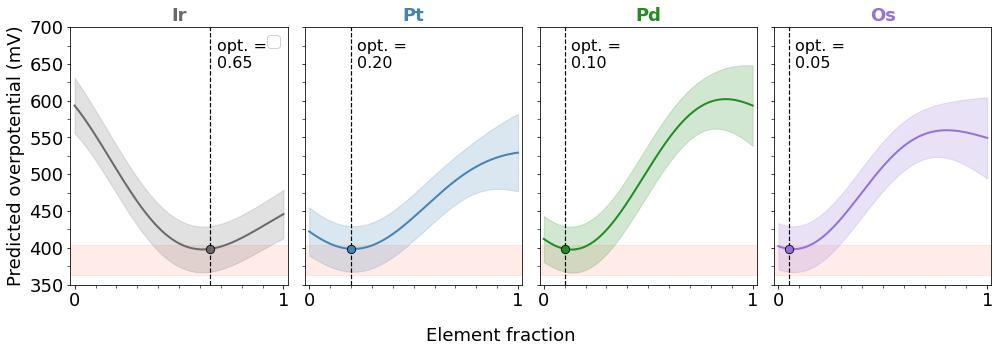

Element sensitivity plots saved.

=== Part 2 Complete ===

=== Element Sensitivity Analysis Complete ===



In [5]:
# ==============================================================================
# ==============================================================================
#   ELEMENT SENSITIVITY ANALYSIS
#   Visualizes how the GPR-predicted overpotential responds to varying a
#   single element's fraction away from the optimal composition
#   (Ir0.65 Pt0.20 Pd0.10 Os0.05), while holding the RELATIVE proportions
#   of the remaining three elements fixed and rescaling them to keep the
#   total composition summing to 1. This produces one 1-D "slice" through
#   the 4-D composition simplex per element, each passing through the same
#   optimal point.
#
#   DEPENDENCIES: uses X_all, y_all, u, s, invScaling, and pipe as left by
#   the LEARNING CURVE section immediately above (X_all/y_all there are
#   the combined training+validation compositions filtered to
#   overpotentials < 700 mV, standardized using Part 1's training-set-only
#   u/s). This section explicitly refits pipe via
#   pipe.fit(X_all, y_all_normalized_full) before use, so it does not
#   depend on whatever intermediate fit state Learning Curve's LOOCV loops
#   left pipe in -- but it DOES require u, s, and invScaling to still be
#   Part 1's (training-set-only) versions. As with the Learning Curve,
#   this section must therefore run BEFORE Part 2, which redefines u, s,
#   invScaling, and pipe for the independently-trained full-dataset model.
#
#   METHOD: for each element (Ir, Pt, Pd, Os in turn), its fraction is
#   swept over 300 evenly-spaced values in [0, 1]. At each swept value f,
#   the remaining three elements are rescaled proportionally to their
#   RELATIVE ratios at the optimal composition so that all four fractions
#   continue to sum to 1 (e.g., sweeping Ir away from its optimal value of
#   0.65 redistributes the remainder across Pt/Pd/Os in the same 0.20 :
#   0.10 : 0.05 ratio they hold at the optimum). The GPR posterior mean
#   and standard deviation are evaluated at each swept point and plotted
#   as a curve with a shaded +/- 1 sigma uncertainty band; the optimal
#   fraction for that element is marked with a vertical dashed line and a
#   scatter point on the curve. A shaded horizontal band shows the
#   experimental overpotential and uncertainty (383.4 +/- 20.4 mV)
#   measured at the optimal composition, for visual reference against the
#   model's predicted curves.
#
#   CAVEATS:
#     - `y_top` is defined but not used anywhere in this section (a
#       leftover from plot layout iteration); harmless, left as-is per
#       the instruction not to modify the provided code.
#     - `ax.legend()` is only called on the first panel, but no plotted
#       artist in this section is given a `label=`, so this will produce
#       an empty legend box (or a "no artists with labels found" warning
#       from matplotlib) rather than an error. This is cosmetic and does
#       not affect the data shown; remove the `ax.legend(...)` call, or
#       add `label=` arguments to the relevant plot calls, if a visible
#       legend is desired.
# ==============================================================================
# ==============================================================================

# ============================================================================
# PART 2: Element Sensitivity Analysis (Improved)
# ============================================================================

print("\n=== Part 2: Element Sensitivity Analysis ===\n")

# Ensure sensitivity analysis uses full active learning dataset
y_all_normalized_full = (y_all - u) / s
pipe.fit(X_all, y_all_normalized_full)

print(f"Sensitivity analysis using model trained on {len(X_all)} compositions")

# Optimal composition [Pt, Pd, Ir, Os] — matches feature vector column order
optimal = np.array([0.20, 0.10, 0.65, 0.05])  # [Pt, Pd, Ir, Os]

# Display order: Ir, Pt, Pd, Os  (element_idx = column in feature vector)
element_names  = ['Ir',       'Pt',        'Pd',           'Os'         ]
element_idx    = [2,           0,            1,              3           ]
element_colors = ['dimgray',  'steelblue', 'forestgreen',  'mediumpurple']

fractions = np.linspace(0, 1, 300)

# ── Figure layout: 1 row × 4 cols, shared y-axis ──────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(14, 4.5),
                         sharey=True, sharex=False)

exp_optimal_op  = 383.39  # mV
exp_optimal_std = 20.36   # mV — experimental uncertainty on the optimal point
y_top           = 700     # top of y-axis

for panel_idx, (name, feat_idx, color, ax) in enumerate(
        zip(element_names, element_idx, element_colors, axes)):

    preds = []
    stds  = []
    opt_frac = optimal[feat_idx]

    for f in fractions:
        remainder  = 1 - f
        others_idx = [i for i in range(4) if i != feat_idx]
        others_opt = optimal[others_idx]
        others_sum = others_opt.sum()

        comp = np.zeros(4)
        comp[feat_idx]   = f
        comp[others_idx] = (others_opt / others_sum * remainder
                            if others_sum > 0
                            else np.full(3, remainder / 3))

        y_norm, y_std_norm = pipe.predict(comp.reshape(1, -1), return_std=True)
        preds.append(invScaling(y_norm)[0])
        stds.append(y_std_norm[0] * s)

    preds = np.array(preds)
    stds  = np.array(stds)

    # ── Uncertainty band ───────────────────────────────────────────────────
    ax.fill_between(fractions, preds - stds, preds + stds,
                    alpha=0.20, color=color, zorder=1)

    # ── GP mean curve ──────────────────────────────────────────────────────
    ax.plot(fractions, preds, color=color, linewidth=2.0, zorder=2)

    # ── Horizontal band: experimental result of the optimal composition ───
    ax.axhspan(exp_optimal_op - exp_optimal_std,
               exp_optimal_op + exp_optimal_std,
               alpha=0.12, color='tomato', zorder=0)
    # ax.axhline(y=exp_optimal_op, color='tomato', linestyle=':',
               # linewidth=1.2, zorder=4,
               # label='Predicted optimal (383 mV)')

    # ── Mark the optimal point on the curve ───────────────────────────────
    opt_curve_idx = np.argmin(np.abs(fractions - opt_frac))
    ax.scatter(opt_frac, preds[opt_curve_idx],
               s=70, color=color, edgecolors='black', linewidth=0.8,
               zorder=5)

    # ── Vertical dashed line at optimal fraction ───────────────────────────
    ax.axvline(x=opt_frac, color='black', linestyle='--',
               linewidth=1.2, zorder=4)

    # ── Optimal annotation: above the band, just right of the dashed line ─
    band_top_at_opt = preds[opt_curve_idx] + stds[opt_curve_idx]
    ann_y = band_top_at_opt + 18  # a little above the band
    ann_y = max(ann_y, 640)       # push to top region regardless of band height
    ax.text(opt_frac + 0.03, ann_y,
            f'opt. =\n{opt_frac:.2f}',
            ha='left', va='bottom', fontsize=16,
            color='black', zorder=6)

    # ── Panel cosmetics ───────────────────────────────────────────────────
    ax.set_title(name, fontsize=18, fontweight='bold', color=color, pad=6)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(350, 700)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['0', '1'])
    ax.tick_params(labelsize=18)
    ax.xaxis.set_minor_locator(MultipleLocator(0.1))
    ax.yaxis.set_minor_locator(MultipleLocator(25))
    ax.tick_params(which='minor', length=3)
    ax.set_xlabel('')  # clear individual labels; shared label added below

    # Only show legend and y-label on first panel
    if panel_idx == 0:
        ax.set_ylabel('Predicted overpotential (mV)', fontsize=18)
        ax.legend(fontsize=16, framealpha=0.9, loc='upper right')

plt.tight_layout()
plt.subplots_adjust(wspace=0.08)
# Single x-axis label centred across all panels
fig.text(0.5, -0.02, 'Element fraction', ha='center', va='top', fontsize=18)
plt.savefig('element_sensitivity.svg', format='svg', bbox_inches='tight')
plt.savefig('element_sensitivity.pdf', format='pdf', bbox_inches='tight')
plt.savefig('element_sensitivity.eps', format='eps', bbox_inches='tight')
plt.show()

print("Element sensitivity plots saved.")
print("\n=== Part 2 Complete ===")
print("\n=== Element Sensitivity Analysis Complete ===\n")

Total rows loaded: 66
Training compositions (<700mV, deduped): 33
Validation compositions (deduped): 18
X_all size (train + filtered validation): 50
Sensitivity analysis using model trained on 50 compositions
Ir: predicted OP at fraction=0.65 -> 421.2 +/- 31.6 mV
Pt: predicted OP at fraction=0.35 -> 421.2 +/- 31.6 mV
Saved plot.


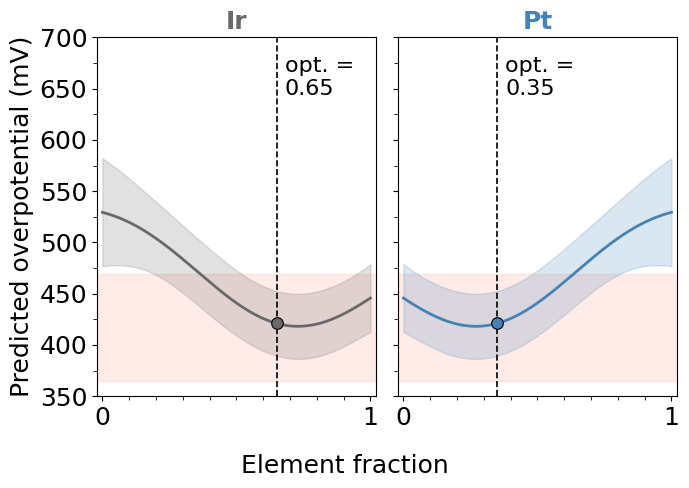

In [10]:
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor as GPR
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from matplotlib.ticker import MultipleLocator
import itertools

plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['text.usetex'] = False

# ---- Data import ----
data_full = pd.read_csv("EC data_std dev.csv", header=0)
data_full = data_full.dropna().reset_index(drop=True)
print(f"Total rows loaded: {len(data_full)}")

# ---- Train / validation split (same row-based split as original script) ----
data_train_all = data_full.iloc[:38].copy()
data_validation_all = data_full.iloc[38:].copy()

def average_duplicates(data):
    grouped = data.groupby(['Pt', 'Pd', 'Ir', 'Os'])
    averaged_data = []
    for composition, group in grouped:
        avg_op = group['Avg OP (mV)'].mean()
        std_dev_avg = np.sqrt(np.sum(group['Std Dev Avg OP (mV)'].values**2)) / len(group)
        averaged_data.append({
            'Pt': composition[0], 'Pd': composition[1],
            'Ir': composition[2], 'Os': composition[3],
            'Avg OP (mV)': avg_op, 'Std Dev Avg OP (mV)': std_dev_avg
        })
    return pd.DataFrame(averaged_data)

data_train_all_averaged = average_duplicates(data_train_all)
data_validation_all_averaged = average_duplicates(data_validation_all)

data_train = data_train_all_averaged[data_train_all_averaged['Avg OP (mV)'] < 700].copy()
data_validation = data_validation_all_averaged.copy()

print(f"Training compositions (<700mV, deduped): {len(data_train)}")
print(f"Validation compositions (deduped): {len(data_validation)}")

X_train_full = data_train[['Pt', 'Pd', 'Ir', 'Os']].values
y_train_full = data_train['Avg OP (mV)'].values
y_train_std = data_train['Std Dev Avg OP (mV)'].values

X_validation = data_validation[['Pt', 'Pd', 'Ir', 'Os']].values
y_validation = data_validation['Avg OP (mV)'].values
y_validation_std = data_validation['Std Dev Avg OP (mV)'].values

# ---- Target standardization (training-set only, Part 1 scale) ----
u = np.mean(y_train_full)
s = np.std(y_train_full)

def invScaling(y_scaled):
    return np.array(y_scaled) * s + u

kernel = RBF() + WhiteKernel()
model = GPR(kernel)
pipe = Pipeline([('scaler', StandardScaler()), ('model', model)])

# Fit on full (filtered) training set (Part 1 "final model")
y_train_normalized = (y_train_full - u) / s
pipe.fit(X_train_full, y_train_normalized)

# ---- Build X_all / y_all as in the Learning Curve section ----
low_op_val_mask = y_validation < 700
X_validation_low = X_validation[low_op_val_mask]
y_validation_low = y_validation[low_op_val_mask]
y_validation_std_low = y_validation_std[low_op_val_mask]

X_all = np.vstack([X_train_full, X_validation_low])
y_all = np.concatenate([y_train_full, y_validation_low])
y_all_std = np.concatenate([y_train_std, y_validation_std_low])

print(f"X_all size (train + filtered validation): {len(X_all)}")

# Refit pipe on X_all (as Element Sensitivity Analysis section does)
y_all_normalized_full = (y_all - u) / s
pipe.fit(X_all, y_all_normalized_full)
print(f"Sensitivity analysis using model trained on {len(X_all)} compositions")

# ==============================================================================
# Element Sensitivity Analysis — Ir & Pt only, optimum = Ir0.65 Pt0.35 (Pd=Os=0)
# ==============================================================================

optimal = np.array([0.35, 0.00, 0.65, 0.00])  # [Pt, Pd, Ir, Os]

element_names  = ['Ir',       'Pt'       ]
element_idx    = [2,           0         ]
element_colors = ['dimgray',  'steelblue']

fractions = np.linspace(0, 1, 300)

fig, axes = plt.subplots(1, 2, figsize=(7, 4.5), sharey=True, sharex=False)

# Experimental reference for Ir0.65Pt0.35 (from your dataset: row with Pt=0.65, Ir=0.35 gives
# 499.14 mV -- NOTE: check which composition you intend; see printed check below)
exp_optimal_op  = 417.4
exp_optimal_std = 52.2

for panel_idx, (name, feat_idx, color, ax) in enumerate(
        zip(element_names, element_idx, element_colors, axes)):

    preds, stds = [], []
    opt_frac = optimal[feat_idx]

    for f in fractions:
        remainder  = 1 - f
        others_idx = [i for i in range(4) if i != feat_idx]
        others_opt = optimal[others_idx]
        others_sum = others_opt.sum()

        comp = np.zeros(4)
        comp[feat_idx]   = f
        comp[others_idx] = (others_opt / others_sum * remainder
                            if others_sum > 0
                            else np.full(3, remainder / 3))

        y_norm, y_std_norm = pipe.predict(comp.reshape(1, -1), return_std=True)
        preds.append(invScaling(y_norm)[0])
        stds.append(y_std_norm[0] * s)

    preds = np.array(preds)
    stds  = np.array(stds)

    ax.fill_between(fractions, preds - stds, preds + stds, alpha=0.20, color=color, zorder=1)
    ax.plot(fractions, preds, color=color, linewidth=2.0, zorder=2)
    ax.axhspan(exp_optimal_op - exp_optimal_std, exp_optimal_op + exp_optimal_std,
               alpha=0.12, color='tomato', zorder=0)

    opt_curve_idx = np.argmin(np.abs(fractions - opt_frac))
    ax.scatter(opt_frac, preds[opt_curve_idx], s=70, color=color,
               edgecolors='black', linewidth=0.8, zorder=5)
    ax.axvline(x=opt_frac, color='black', linestyle='--', linewidth=1.2, zorder=4)

    band_top_at_opt = preds[opt_curve_idx] + stds[opt_curve_idx]
    ann_y = max(band_top_at_opt + 18, 640)
    ax.text(opt_frac + 0.03, ann_y, f'opt. =\n{opt_frac:.2f}',
            ha='left', va='bottom', fontsize=16, color='black', zorder=6)

    ax.set_title(name, fontsize=18, fontweight='bold', color=color, pad=6)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(350, 700)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['0', '1'])
    ax.tick_params(labelsize=18)
    ax.xaxis.set_minor_locator(MultipleLocator(0.1))
    ax.yaxis.set_minor_locator(MultipleLocator(25))
    ax.tick_params(which='minor', length=3)
    ax.set_xlabel('')

    if panel_idx == 0:
        ax.set_ylabel('Predicted overpotential (mV)', fontsize=18)

    print(f"{name}: predicted OP at fraction={opt_frac:.2f} -> {preds[opt_curve_idx]:.1f} +/- {stds[opt_curve_idx]:.1f} mV")

plt.tight_layout()
plt.subplots_adjust(wspace=0.08)
fig.text(0.5, -0.02, 'Element fraction', ha='center', va='top', fontsize=18)
plt.savefig('element_sensitivity_IrPt_binary.svg', format='svg', bbox_inches='tight')
plt.savefig('element_sensitivity_IrPt_binary.pdf', format='pdf', bbox_inches='tight')
plt.savefig('element_sensitivity_IrPt_binary.png', format='png', bbox_inches='tight', dpi=150)

print("Saved plot.")


SHAP ANALYSIS - Feature Importance

Creating SHAP explainer...
Calculating SHAP values (this may take a moment)...


  0%|          | 0/50 [00:00<?, ?it/s]


Feature Importance (Mean |SHAP|):
  Ir: 26.994 mV
  Pd: 26.108 mV
  Os: 23.325 mV
  Pt: 9.506 mV

Generating SHAP summary plot (beeswarm)...


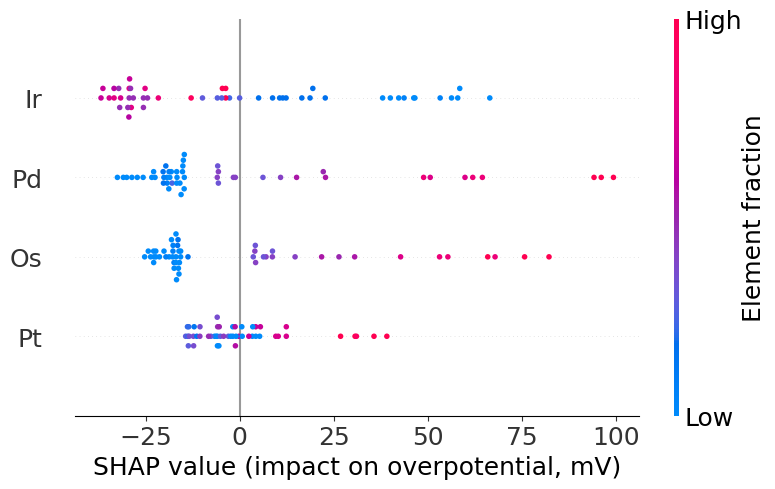


=== SHAP Analysis Complete ===


In [6]:
# ==============================================================================
# ==============================================================================
#   SHAP ANALYSIS
#   Computes SHAP (SHapley Additive exPlanations) values to quantify each
#   element's (Pt, Pd, Ir, Os) contribution to the GPR model's predicted
#   overpotential, using a model-agnostic KernelExplainer, and visualizes
#   the result as a beeswarm summary plot.
#
#   DEPENDENCIES: uses `pipe` (specifically pipe.named_steps['scaler'] and
#   pipe.named_steps['model']) and `X_all`, `s` exactly as left by the
#   ELEMENT SENSITIVITY ANALYSIS section immediately above. This section
#   does NOT refit pipe itself, so it relies entirely on Element
#   Sensitivity's prior call to pipe.fit(X_all, y_all_normalized_full).
#
#   NOTE ON DATASET SCOPE: the original comment below ("Scale all 51
#   compositions") reflects an UNFILTERED combination of the 33 training
#   compositions with all 18 validation compositions (33 + 18 = 51 total),
#   as used in the before/after active-learning comparison discussed
#   earlier. The X_all inherited here instead comes from the LEARNING
#   CURVE section, which filters the validation set to overpotentials
#   < 700 mV -- so X_all at this point in the script will generally
#   contain FEWER than 51 rows, and the printed compositions count will
#   not literally read "51". This is INTENTIONAL: the SHAP analysis is
#   meant to explain the model using only the filtered (<700 mV) data
#   points, consistent with the Learning Curve and Element Sensitivity
#   Analysis sections above. No code changes are needed for this; it is
#   noted here only so the mismatch between the comment text and the
#   actual composition count is not mistaken for a bug.
#
#   OTHER CAVEATS:
#     - `plt.style.use('default')` resets matplotlib's global rcParams,
#       which would otherwise override the Arial/Helvetica font settings
#       configured at the top of this script for all later figures (Part
#       2's composition-screening plots and the Full-Dataset Parity
#       Plot). A font-restoration step has been added immediately after
#       this section (see "RESTORE FONT SETTINGS" below) specifically to
#       counteract this, so that every figure in the script -- before and
#       after the SHAP Analysis -- uses the same font family.
#     - shap.KernelExplainer has O(n^2)-ish cost in the number of
#       background/evaluation samples and may take a noticeable amount of
#       time to run even for datasets of this size ("this may take a
#       moment" in the printed output is accurate).
#     - Requires the `shap` package (pip install shap), which is not used
#       elsewhere in this script and is not part of the standard
#       numpy/pandas/scikit-learn/matplotlib stack assumed above.
#     - SHAP values are computed on the model's NORMALIZED prediction
#       scale (gpr_model.predict operates on standardized targets) and are
#       rescaled to mV by multiplying by `s` only (NOT by adding `u`),
#       which is the correct transformation for additive per-feature
#       contributions (SHAP values represent deviations from a baseline
#       expected value, not absolute predictions, so they should not be
#       shifted by the mean).
# ==============================================================================
# ==============================================================================

# ============================================================================
# SHAP Analysis
# ============================================================================
print("\n" + "="*80)
print("SHAP ANALYSIS - Feature Importance")
print("="*80)
import shap
# Reset style before any plotting
plt.style.use('default')
# Extract the trained GPR model from the pipeline
scaler = pipe.named_steps['scaler']
gpr_model = pipe.named_steps['model']
# Scale all 51 compositions
X_all_scaled = scaler.transform(X_all)
# Create SHAP explainer and calculate values
print("\nCreating SHAP explainer...")
explainer = shap.KernelExplainer(gpr_model.predict, X_all_scaled)
print("Calculating SHAP values (this may take a moment)...")
shap_values = explainer.shap_values(X_all_scaled)
# Scale SHAP values back to mV
shap_values_scaled = shap_values * s
feature_names = ['Pt', 'Pd', 'Ir', 'Os']
# Print feature importance
print("\nFeature Importance (Mean |SHAP|):")
mean_abs_shap = np.mean(np.abs(shap_values_scaled), axis=0)
feature_importance = sorted(zip(feature_names, mean_abs_shap),
                            key=lambda x: x[1], reverse=True)
for feature, importance in feature_importance:
    print(f"  {feature}: {importance:.3f} mV")
# ============================================================================
# SHAP Beeswarm Plot
# ============================================================================
print("\nGenerating SHAP summary plot (beeswarm)...")
shap.summary_plot(shap_values_scaled, X_all,
                  feature_names=feature_names,
                  show=False,
                  plot_size=(8, 5))
fig = plt.gcf()
axes = fig.axes
main_ax = axes[0]
cbar_ax = axes[1]
fig.patch.set_facecolor('white')
main_ax.set_facecolor('white')
main_ax.set_xlabel('SHAP value (impact on overpotential, mV)', fontsize=18)
main_ax.tick_params(labelsize=18)
cbar_ax.set_ylabel('Element fraction', fontsize=18)
cbar_ax.tick_params(labelsize=18)
if len(axes) > 2:
    for extra_ax in axes[2:]:
        extra_ax.remove()
plt.tight_layout()
plt.savefig('shap_summary_beeswarm.svg', format='svg', bbox_inches='tight',
            facecolor='white')
plt.savefig('shap_summary_beeswarm.pdf', format='pdf', bbox_inches='tight',
            facecolor='white')
plt.show()
print("\n=== SHAP Analysis Complete ===")

# ---- Restore font settings ----
# plt.style.use('default') above reset matplotlib's global rcParams,
# which would otherwise apply matplotlib's default font to every figure
# generated from this point onward. Reassert the same font configuration
# set at the top of this script so all figures (before and after the
# SHAP Analysis) are rendered with consistent fonts.
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['font.family'] = 'sans-serif'

PART 2: FULL MODEL TRAINING ON ALL SAMPLES

AVERAGING DUPLICATE COMPOSITIONS IN FULL DATASET (samples 1-55):

Found 3 duplicates for composition: Pt=0.0, Pd=0.0, Ir=1.0, Os=0.0
  Original OPs: [468.      455.47    441.92333]
  Original errors: [27.0555   7.81025 17.46616]
  Averaged OP: 455.13 ± 11.05 mV

Found 3 duplicates for composition: Pt=0.1, Pd=0.0, Ir=0.9, Os=0.0
  Original OPs: [411.      401.80333 447.59   ]
  Original errors: [ 6.08276  6.65833 14.3248 ]
  Averaged OP: 420.13 ± 5.64 mV

Found 2 duplicates for composition: Pt=0.1, Pd=0.1, Ir=0.7, Os=0.1
  Original OPs: [403.33333 394.13667]
  Original errors: [1.52753 1.1547 ]
  Averaged OP: 398.74 ± 0.96 mV

Found 2 duplicates for composition: Pt=0.35, Pd=0.0, Ir=0.65, Os=0.0
  Original OPs: [465.8     424.92333]
  Original errors: [4.93288 7.17403]
  Averaged OP: 445.36 ± 4.35 mV

Found 2 duplicates for composition: Pt=0.4, Pd=0.0, Ir=0.5, Os=0.1
  Original OPs: [419.   409.47]
  Original errors: [2.64575 2.64575]
  Average

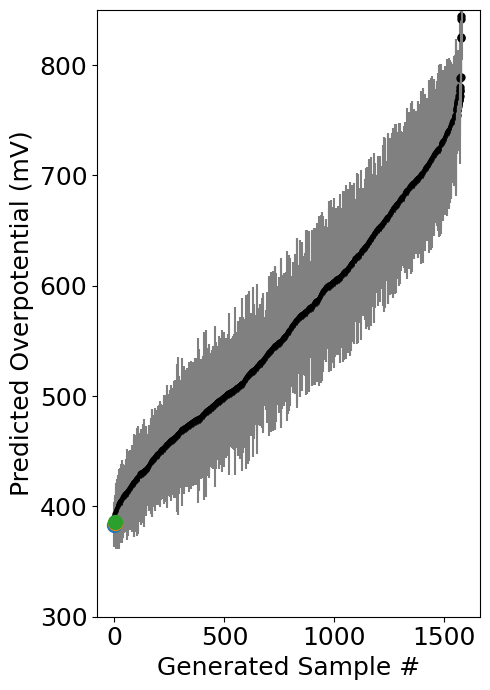


Zoomed view saved as:
  - OER_predicted_compositions_zoomed.svg
  - OER_predicted_compositions_zoomed.pdf


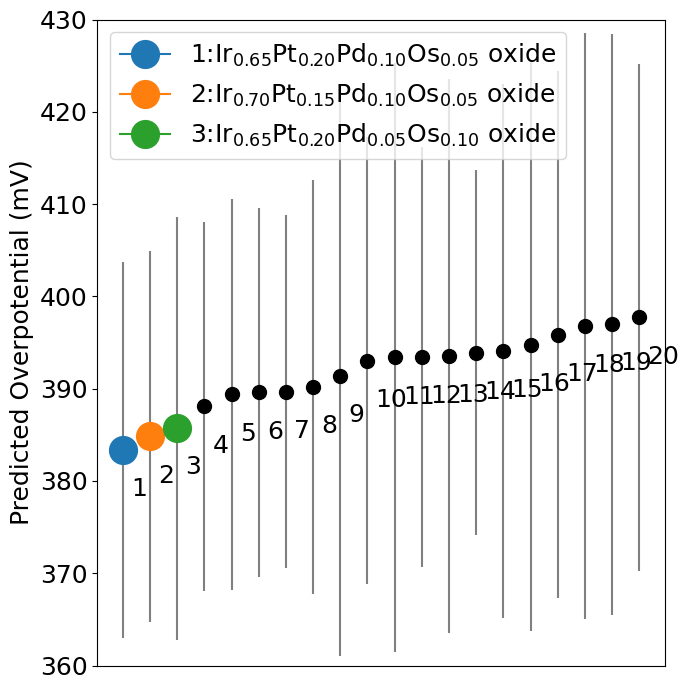


=== Analysis Complete ===


In [7]:
# ==============================================================================
# ==============================================================================
#   PART 2
#   Re-training of the GPR model on the complete dataset (all 55 measured
#   samples, duplicate-averaged, no overpotential filter applied) and
#   exhaustive screening of the composition space to identify the globally
#   optimal composition and the optimal Ir-Pt binary composition predicted
#   by the fully-trained model.
#
#   NOTE: As described in the header of this file, this model is trained
#   independently of the Part 1 training-set-only model and uses its own
#   target standardization constants (u, s). Its outputs are therefore not
#   expected to numerically reproduce the Part 1 results, by design -- this
#   section reflects the effect of incorporating the full dataset (including
#   what was previously held out as the validation set) into model training.
# ==============================================================================
# ==============================================================================

# ============================================================================
# PART 2: Full Model Training and Composition Prediction
# ============================================================================

# Reload data for second part - now using ALL 55 samples
data = pd.read_csv("EC data_std dev.csv", header=0)

print("="*80)
print("PART 2: FULL MODEL TRAINING ON ALL SAMPLES")
print("="*80)

# Average duplicates across ALL 55 samples using the same function
print("\nAVERAGING DUPLICATE COMPOSITIONS IN FULL DATASET (samples 1-55):")
print("="*80)
data_averaged = average_duplicates(data)
print(f"\nFull data: {len(data)} rows → {len(data_averaged)} unique compositions")

# ---- Feature / target extraction (full dataset, no overpotential filter) ----
# Extract features and target
X = data_averaged[['Pt', 'Pd', 'Ir', 'Os']].values
y = data_averaged['Avg OP (mV)'].values

print(f"\nTraining on {len(X)} unique compositions (samples 1-55)")

# ---- Target standardization (recomputed from the full dataset) ----
# Standardize target variable
u = np.mean(y)
s = np.std(y)
y_standardized = (y - u) / s

def invScaling(y):
    return np.array(y) * s + u

# ---- Model fit on the complete dataset ----
# Initialize and fit model - SAME KERNEL AS PART 1 for consistency
kernel = RBF() + WhiteKernel()
model = GPR(kernel)
pipe = Pipeline([('scaler', StandardScaler()), ('model', model)])
pipe.fit(X, y_standardized)

# ---- Exhaustive composition-space screening (full-data model) ----
# Create new data points - generate all possible compositions
values = np.arange(0, 1.05, 0.05)
all_columns = list(itertools.product(values, repeat=4))
filter_columns = [c for c in all_columns if sum(c) == 1]
matrix = np.array(filter_columns).T
X_new = matrix.T

print(f"\nGenerated {len(X_new)} valid compositions for screening")

# Predict using the model
y_new_standardized, y_std_standardized = pipe.predict(X_new, return_std=True)

# Convert back to overpotential (mV)
y_new = invScaling(y_new_standardized)
y_std = y_std_standardized * s

idx = np.argsort(y_new)

# ---- Global minimum (full composition space) ----
# Find and print the best composition with lowest predicted overpotential
best_idx = idx[0]  # First index after sorting is the lowest
best_composition = X_new[best_idx]
best_overpotential = y_new[best_idx]
best_uncertainty = y_std[best_idx]

print("\n" + "="*80)
print("BEST COMPOSITION (Lowest Predicted Overpotential):")
print("="*80)
print(f"Composition: Ir={best_composition[2]:.2f}, Pt={best_composition[0]:.2f}, Pd={best_composition[1]:.2f}, Os={best_composition[3]:.2f}")
print(f"Predicted Overpotential: {best_overpotential:.2f} ± {best_uncertainty:.2f} mV")
print("="*80 + "\n")

# ---- Restricted screening: Ir-Pt binary subspace (Pd = 0, Os = 0) ----
# Find the best Ir-Pt binary composition (Pd=0, Os=0)
print("="*80)
print("BEST Ir-Pt BINARY COMPOSITION (Pd=0, Os=0):")
print("="*80)

# Filter to only Ir-Pt compositions (Pd=0 and Os=0)
is_IrPt_binary = (X_new[:, 1] == 0) & (X_new[:, 3] == 0)  # Pd (index 1) and Os (index 3) = 0
IrPt_indices = np.where(is_IrPt_binary)[0]

if len(IrPt_indices) > 0:
    # Get predictions for Ir-Pt compositions only
    y_IrPt = y_new[IrPt_indices]
    y_std_IrPt = y_std[IrPt_indices]
    X_IrPt = X_new[IrPt_indices]
    
    # Find the best Ir-Pt composition
    best_IrPt_idx = np.argmin(y_IrPt)
    best_IrPt_composition = X_IrPt[best_IrPt_idx]
    best_IrPt_overpotential = y_IrPt[best_IrPt_idx]
    best_IrPt_uncertainty = y_std_IrPt[best_IrPt_idx]
    
    print(f"Composition: Ir={best_IrPt_composition[2]:.2f}, Pt={best_IrPt_composition[0]:.2f}")
    print(f"Predicted Overpotential: {best_IrPt_overpotential:.2f} ± {best_IrPt_uncertainty:.2f} mV")
    print(f"Number of Ir-Pt binary compositions evaluated: {len(IrPt_indices)}")
    
    # Show top 5 Ir-Pt compositions
    print("\nTop 5 Ir-Pt binary compositions:")
    top5_IrPt_indices = np.argsort(y_IrPt)[:5]
    for i, idx_local in enumerate(top5_IrPt_indices):
        comp = X_IrPt[idx_local]
        print(f"  {i+1}. Ir={comp[2]:.2f}, Pt={comp[0]:.2f}: {y_IrPt[idx_local]:.2f} ± {y_std_IrPt[idx_local]:.2f} mV")
else:
    print("No Ir-Pt binary compositions found in the generated set")

print("="*80 + "\n")

# ---- Composition-screening plot: full grid, ranked by predicted overpotential ----
# Plot results - Full view (elongated for side-by-side combination)
plt.figure(figsize=(5, 7))

# Create simple text labels - NO LaTeX
labels = [f'Ir={X_new[idx[i], 2]:.2f} Pt={X_new[idx[i], 0]:.2f} Pd={X_new[idx[i], 1]:.2f} Os={X_new[idx[i], 3]:.2f}' 
          for i in range(len(y_new))]

for ii, yi in enumerate(y_new[idx]):
    plt.errorbar(ii, yi, y_std[idx][ii], marker='None', color='gray', linestyle='None', zorder=1)
    if ii < 3:
        plt.plot(ii, yi, marker='o', markersize=10, label='{}:{}'.format(ii+1, labels[ii]))
    else:
        plt.plot(ii, yi, marker='o', markersize=5, color='k', linestyle='None', zorder=1)

plt.ylim(300, 850)
plt.xlabel('Generated Sample #', fontsize=18)
plt.ylabel('Predicted Overpotential (mV)', fontsize=18)
plt.tick_params(labelsize=18)
plt.tight_layout()

# Save the full view as SVG
plt.savefig('OER_predicted_compositions_full.svg', format='svg', bbox_inches='tight')
plt.savefig('OER_predicted_compositions_full.pdf', format='pdf', bbox_inches='tight')
print("\nFull view saved as:")
print("  - OER_predicted_compositions_full.svg")
print("  - OER_predicted_compositions_full.pdf")

plt.show()

# ---- Zoomed-in view: top 20 lowest-overpotential candidate compositions ----
# Zooming in on the best performing compositions (top 20 samples for increased visibility)
zoomed_indices = np.argsort(y_new)[:20]

plt.figure(figsize=(7, 7))

# Create LaTeX-formatted labels for zoomed view with subscripts
labels_zoomed = [f'Ir$_{{{X_new[zoomed_indices[i], 2]:.2f}}}$Pt$_{{{X_new[zoomed_indices[i], 0]:.2f}}}$Pd$_{{{X_new[zoomed_indices[i], 1]:.2f}}}$Os$_{{{X_new[zoomed_indices[i], 3]:.2f}}}$ oxide' 
                 for i in range(len(zoomed_indices))]

for ii, yi in enumerate(y_new[zoomed_indices]):
    plt.errorbar(ii, yi, y_std[zoomed_indices][ii], marker='None', color='gray', linestyle='None', zorder=1)
    if ii < 3:
        plt.plot(ii, yi, marker='o', markersize=20, label='{}:{}'.format(ii+1, labels_zoomed[ii]))
        plt.annotate(ii+1, (ii+0.3, yi-5), fontsize=18)
    else:
        plt.plot(ii, yi, marker='o', markersize=10, color='k', linestyle='None', zorder=1)
        plt.annotate(ii+1, (ii+0.3, yi-5), fontsize=18)

# Set x-axis to show only whole numbers
plt.gca().xaxis.set_major_locator(MultipleLocator(1))

# Remove x-axis label and ticks
plt.gca().set_xticks([])  # Remove tick marks
plt.gca().set_xlabel('')  # Remove x-axis label

plt.ylim(360, 430)
plt.ylabel('Predicted Overpotential (mV)', fontsize=18)
plt.legend(fontsize=18, loc='upper left')
plt.tick_params(labelsize=18)
plt.tight_layout()

# Save the zoomed view as SVG
plt.savefig('OER_predicted_compositions_zoomed.svg', format='svg', bbox_inches='tight')
plt.savefig('OER_predicted_compositions_zoomed.pdf', format='pdf', bbox_inches='tight')
print("\nZoomed view saved as:")
print("  - OER_predicted_compositions_zoomed.svg")
print("  - OER_predicted_compositions_zoomed.pdf")

plt.show()

print("\n=== Analysis Complete ===")


FULL-DATASET (IN-SAMPLE) FIT SUMMARY:
Number of unique compositions: 54
In-sample MAE: 4.8 mV
NOTE: this MAE reflects in-sample fit, not cross-validated performance.



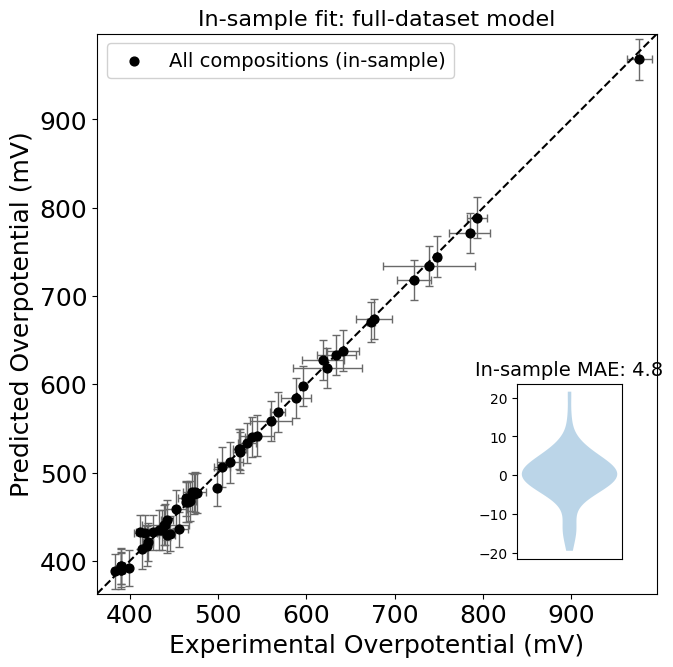


=== Full-Dataset Parity Plot (In-Sample) Complete ===


In [8]:
# ==============================================================================
# ==============================================================================
#   FULL-DATASET PARITY PLOT (IN-SAMPLE FIT)
#   Generates a parity plot (experimental vs. predicted overpotential) using
#   the Part 2 model -- i.e., the GPR model trained on ALL measured
#   compositions (samples 1-55, duplicate-averaged, no overpotential filter).
#
#   *** IMPORTANT CAVEAT ***
#   Unlike the Part 1 parity plot (which uses leave-one-out cross-validated
#   predictions -- each point predicted by a model that did NOT see that
#   point during training), this plot evaluates the Part 2 model on the
#   SAME data used to fit it. These are therefore IN-SAMPLE predictions,
#   not an estimate of generalization/held-out performance. In-sample fit
#   quality is expected to look better than true predictive performance
#   and should not be interpreted as a validation metric. This plot is
#   included to visualize how well the fully-trained model reproduces the
#   complete experimental dataset it was built from, not to assess how it
#   would perform on unseen compositions (Part 1's LOOCV plot serves that
#   purpose).
# ==============================================================================
# ==============================================================================

# Experimental uncertainties for the full (duplicate-averaged) dataset
y_full_exp_std = data_averaged['Std Dev Avg OP (mV)'].values

# In-sample predictions from the Part 2 model (trained on X, y_standardized)
y_full_pred_norm, y_full_pred_std_norm = pipe.predict(X, return_std=True)
y_full_pred = invScaling(y_full_pred_norm)
y_full_pred_std = y_full_pred_std_norm * s

# In-sample residuals (for MAE annotation; NOT a cross-validated error estimate)
y_full_errors = y_full_pred - y

print("\n" + "="*80)
print("FULL-DATASET (IN-SAMPLE) FIT SUMMARY:")
print("="*80)
print(f"Number of unique compositions: {len(X)}")
print(f"In-sample MAE: {np.mean(np.abs(y_full_errors)):.1f} mV")
print("NOTE: this MAE reflects in-sample fit, not cross-validated performance.")
print("="*80 + "\n")

plt.figure(figsize=(7, 7))

# Plot all compositions with experimental and predictive-uncertainty error bars
plt.errorbar(y, y_full_pred,
             xerr=y_full_exp_std,      # Horizontal error bars (experimental uncertainty)
             yerr=y_full_pred_std,     # Vertical error bars (prediction uncertainty)
             marker='None', color='dimgray', linestyle='None',
             linewidth=1, capsize=3, capthick=1, zorder=1)
plt.scatter(y, y_full_pred, marker='o', s=40, color='black',
            zorder=2, label='All compositions (in-sample)')

# Diagonal line (parity / y = x reference line)
plot_min = min(y.min(), y_full_pred.min()) - 20
plot_max = max(y.max(), y_full_pred.max()) + 20
plt.plot([plot_min, plot_max], [plot_min, plot_max], 'k--')
plt.xlim(plot_min, plot_max)
plt.ylim(plot_min, plot_max)
plt.xlabel('Experimental Overpotential (mV)', fontsize=18)
plt.ylabel('Predicted Overpotential (mV)', fontsize=18)
plt.title('In-sample fit: full-dataset model', fontsize=16)
plt.tick_params(labelsize=18)
plt.legend(fontsize=14, loc='upper left', framealpha=0.9)

# Inset violin plot of in-sample residuals, annotated with in-sample MAE
inset = plt.axes([.75, .2, .15, .25])
plt.violinplot(y_full_errors, showextrema=False)
plt.xticks([])
plt.title(f'In-sample MAE: {np.mean(np.abs(y_full_errors)):.1f}', fontsize=14)

plt.subplots_adjust(top=0.95, bottom=0.15, left=0.15, right=0.95)

plt.savefig('overpotential_prediction_full_dataset_insample.svg', format='svg', bbox_inches='tight')

plt.show()

print("\n=== Full-Dataset Parity Plot (In-Sample) Complete ===")